# Naive Forecasting Models

*Persistence, seasonal-naive, and how we measure forecast quality*

## Welcome

We have a clean preprocessing chain in place. Now we build our **first real forecasting models** — and they are deliberately as simple as it gets. No training, no parameters, no neural networks. Just two short rules of thumb that domain experts have used to forecast time series for decades.

Before we build them we need to answer two practical questions:

1. *How will we **measure** forecast quality?* — MAE, RMSE and R&sup2; are not interchangeable; each tells a different story.
2. *What does "the forecast horizon *h*" really mean in hourly data?* A 1-hour forecast and a 12-hour forecast are very different problems even though only one number changes.

Then we implement the two naive forecasters, run them at *h* ∈ {1, 6, 12} on PM2.5 and O&#8323;, and end with a tidy **six-by-two benchmark table**.

**By the end of this notebook** you will have:

1. Understood why forecasting needs metrics that respect *time order* and *scale*.
2. Known how MAE / RMSE / R&sup2; differ and what their values mean for pollutant predictions.
3. Made the forecast horizon *h* tangible — what "predict 12 h ahead" really means and why it gets harder as *h* grows.
4. Built and evaluated **persistence** and **seasonal-naive** forecasts for two pollutants at three horizons — six settings in total.
5. Discovered that **the same naive rule that wins for PM2.5 fails spectacularly for O&#8323;** (and vice versa) — a property of the time series, not of the rule.

---
## 1. What is a naive forecasting model?

A **naive forecasting model** is a predictor with **no learnable parameters**. It just applies a tiny, fixed rule to the data it has seen so far.

Two classical naive rules from forecasting practice:

- **Persistence** — *"What will happen next is what's happening now."* Set *ŷ*(*t*+*h*) = *y*(*t*). Used in weather forecasting since the 19th century. Works well whenever the time series is *autocorrelated* — i.e. values close in time look like each other.
- **Seasonal-naive (24h)** — *"What will happen next is what happened exactly 24 hours ago at the same time of day."* Set *ŷ*(*t*+*h*) = *y*(*t*+*h*−24). Useful whenever the series has a strong daily cycle.

These models are *intentionally* the simplest possible. That is their value: they tell us *how easy or hard the problem is* in absolute terms. A persistence MAE of 1 means the series barely changes; a persistence MAE of 100 means the series is wildly volatile. Either way we now have a number to interpret, with no fitting required.

Both rules can be implemented in **one line of code** and require zero training data — they are exactly the kind of "sanity check first" tool every forecasting practitioner runs before reaching for anything fancier.

---
## 2. How we measure forecast quality

Every forecasting model — naive or sophisticated — produces a vector of predictions **ŷ** = (*ŷ*<sub>1</sub>, …, *ŷ*<sub>n</sub>) for the test set, where the true values are **y** = (*y*<sub>1</sub>, …, *y*<sub>n</sub>). We need to **summarise** how close the two are.

Three metrics are standard in time-series forecasting. They are *not* interchangeable — each captures a different aspect of error.

### 2.1 Mean Absolute Error (MAE)

$$ \mathrm{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right| $$

- **Units:** same as the target. For PM2.5 in &micro;g/m&sup3;, MAE is in &micro;g/m&sup3;. *"On average we are off by X &micro;g/m&sup3;."*
- **Sensitivity:** treats all errors equally — a 50 &micro;g/m&sup3; miss counts the same as ten 5 &micro;g/m&sup3; misses.
- **Best for:** when we want a *typical* error number that's robust to occasional bad predictions.

### 2.2 Root Mean Squared Error (RMSE)

$$ \mathrm{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$

- **Units:** same as the target.
- **Sensitivity:** *squares* the errors before averaging. A 50 &micro;g/m&sup3; miss counts as much as **a hundred** 5 &micro;g/m&sup3; misses (because 50² = 2500 and 5² = 25). RMSE punishes occasional large errors.
- **Best for:** when *large* errors are especially bad (e.g. underestimating a pollution episode that triggers a health alert).

Always: RMSE ≥ MAE. The bigger the gap between them, the more *spread out* the errors are. RMSE = MAE means errors are all about the same size.

### 2.3 Coefficient of determination R&sup2;

$$ R^2 \;=\; 1 \;-\; \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

where *ȳ* is the **mean of the truth**. Equivalent to *"fraction of variance explained"*.

- **Units:** dimensionless. Compare across different pollutants directly.
- **Range:** R² = 1 means perfect predictions. R² = 0 means **the model is no better than always predicting the mean**. R² < 0 means the model is **worse than predicting the mean** — it's actively hurtful.
- **Best for:** comparing across different problems, or detecting that a model has *failed* (negative R&sup2; is unmissable).

### Why we report all three

MAE and RMSE tell us how big the errors are *in &micro;g/m&sup3;*. R&sup2; tells us how the model compares to the *trivial mean predictor*. If we only reported MAE we wouldn't notice that a particular MAE is *worse than the mean*; if we only reported R&sup2; we wouldn't know whether 0.95 corresponds to errors of 1 unit or 100 units. We use both axes.

### A toy example to fix intuition

Suppose we have 5 hours of PM2.5 truth and three different forecasts:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import forecasting_utils as fu

np.random.seed(0)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [2]:
# Toy: 5 hours of truth and three candidate forecasts
y_true = np.array([20.0, 30.0, 50.0, 80.0, 40.0])      # truth
f_close   = np.array([22.0, 28.0, 53.0, 78.0, 42.0])    # close everywhere
f_one_big = np.array([20.0, 30.0, 50.0, 80.0, 200.0])   # perfect except one huge miss
f_mean    = np.full(5, y_true.mean())                   # always predict the mean

def all_three(y, yhat):
    return {
        "MAE":  mean_absolute_error(y, yhat),
        "RMSE": float(np.sqrt(mean_squared_error(y, yhat))),
        "R²":   r2_score(y, yhat),
    }

print(pd.DataFrame({
    "close":             all_three(y_true, f_close),
    "one big miss":      all_three(y_true, f_one_big),
    "always mean":       all_three(y_true, f_mean),
}).round(2).to_string())

      close  one big miss  always mean
MAE    2.20         32.00        16.80
RMSE   2.24         71.55        20.59
R²     0.99        -11.08         0.00


Read the table:

- **"close"** — small errors everywhere. MAE and RMSE are essentially identical (2.20 vs 2.24), R&sup2; is high. *MAE ≈ RMSE* tells us the errors are all roughly the same size.
- **"one big miss"** — four perfect predictions and one prediction off by 160. MAE jumps to **32** (the average is now driven entirely by the single bad point); RMSE jumps to **72** — much further, because squaring the 160 makes that outlier dominate the average. R&sup2; turns *deeply* negative: a single bad prediction is enough to make this forecast worse than always predicting the mean.
- **"always mean"** — by definition R&sup2; = 0. MAE here equals the *mean absolute deviation* of the data — a useful upper bound for how bad a sane forecaster can be.

Take-away: if a single big error is *operationally bad* (e.g. a health alert that we missed), use **RMSE** to surface it. If you want a *typical* error number, use **MAE**. **R&sup2;** tells you whether the model is useful at all relative to a constant baseline.

---
## 3. The forecast horizon *h* — what does it really mean?

Recall the setup: at every hour *t*, we have a window of the **last 24 hours** of observations and we want to predict what happens ***h* hours later**.

We will explore three horizons. They sound similar, but they correspond to **very different forecasting problems**:

| *h* | What it means | Air-quality intuition |
|---|---|---|
| **1 h** | predict the pollutant one hour from now | The atmosphere barely moves in an hour. Whatever was happening at *t* is mostly still happening at *t*+1. **Strong autocorrelation dominates.** |
| **6 h** | predict the pollutant six hours from now | A weather front can pass through, the rush-hour cycle changes, photochemistry shifts. **Both autocorrelation and slow drivers matter.** |
| **12 h** | predict the pollutant twelve hours from now | Half a day forward — *night becomes day* (or vice versa). For O&#8323; this means the daily cycle has roughly *flipped*; for PM2.5 a slowly drifting episode may have moved on the wind. **The daily cycle (where it exists) dominates over short-term persistence.** |

Below we plot a stretch of test-set PM2.5 and O&#8323; alongside three "copies" of the same series shifted by *h* = 1, 6 and 12 hours. The shifted curve is exactly what the **persistence** rule would predict — and we can see how its match to the truth gets worse as *h* grows.

In [3]:
# Same preprocessing chain as NB1: load -> wind -> cyclic features
df = fu.load_clean_station("Nongzhanguan")
df = fu.add_wind_components(df).dropna(subset=["wind_u", "wind_v"]).reset_index(drop=True)
df = fu.add_cyclic_features(df)
print(f"Rows: {len(df):,}")

Rows: 33,114


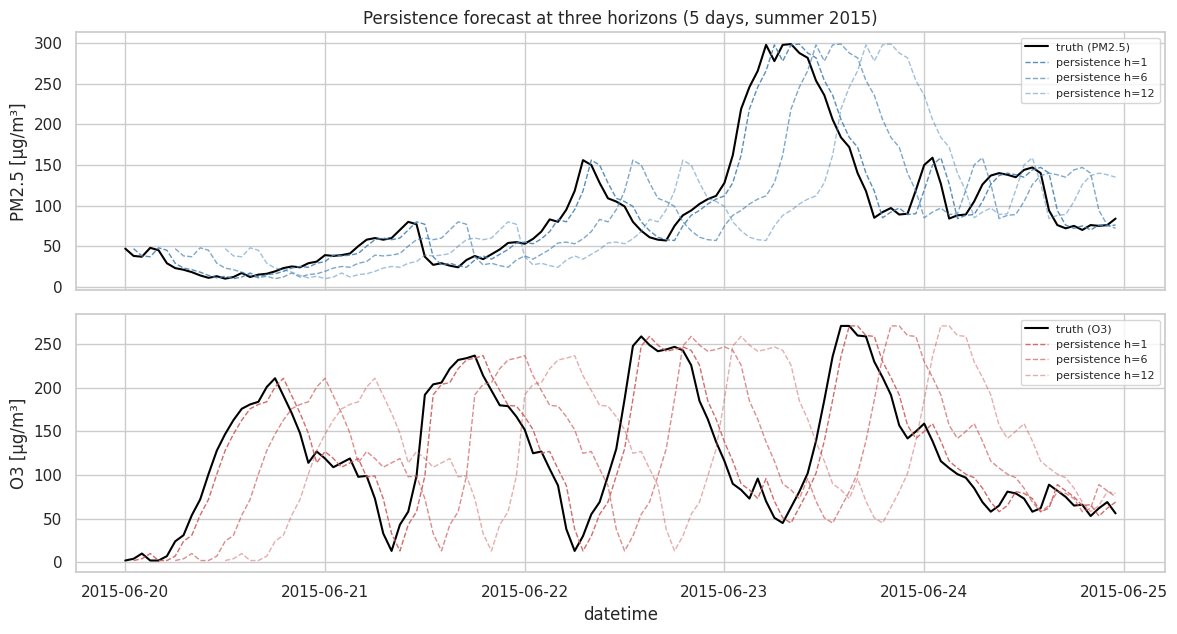

In [4]:
# Visualise: what does "shift by h hours" actually look like?
# Pick a 5-day clean slice from summer 2015 (gap-free)
start = pd.Timestamp("2015-06-20"); end = pd.Timestamp("2015-06-25")
sl = df[(df["datetime"] >= start) & (df["datetime"] < end)].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
for ax, target, color in zip(axes, ["PM2.5", "O3"], ["steelblue", "indianred"]):
    ax.plot(sl["datetime"], sl[target], color="black", linewidth=1.5, label=f"truth ({target})")
    for h, alpha, ls in [(1, 0.9, "--"), (6, 0.7, "--"), (12, 0.5, "--")]:
        shifted = sl[target].shift(h)
        ax.plot(sl["datetime"], shifted, color=color, linewidth=1.0, alpha=alpha,
                linestyle=ls, label=f"persistence h={h}")
    ax.set_ylabel(f"{target} [\u00b5g/m\u00b3]")
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_title("Persistence forecast at three horizons (5 days, summer 2015)")
axes[1].set_xlabel("datetime")
plt.tight_layout(); plt.show()

Read the **black** line as truth and the **coloured dashed** lines as the persistence forecast at each horizon (just the truth shifted right by *h* hours).

- **PM2.5 (top).** Even at *h* = 12 the forecast is *roughly* in the right ballpark — PM2.5 episodes drift slowly over many hours, so even "12 h ago" is often a passable prediction.
- **O&#8323; (bottom).** At *h* = 1 the forecast is excellent. At *h* = 6 it is already a **quarter-cycle off** (6 / 24 of the daily cycle) — when the truth peaks at noon, the forecast still says "morning levels". At *h* = 12 the forecast is a **half-cycle off** and **inverts** the truth: the persistence prediction for noon ozone is *midnight ozone*, which is roughly its opposite.

Two pollutants, two completely different behaviours of the same naive rule. The numbers in this notebook will quantify exactly that.

---
## 4. Setup — helpers we will reuse

Two tiny helpers do the actual prediction work:

- `persistence(X)` returns the value at the **last hour** of each window — that's *y*(*t*), the forecast for *y*(*t*+*h*).
- `seasonal(X, h)` returns the value at position ***h*−1** of the window — for *T* = 24 this is *y*(*t*+*h*−24), the same hour 24 h earlier.

Both assume the **target column is at index 0** of the feature axis — which is exactly how `fu.features_min` arranges the columns.

In [5]:
def persistence(X):
    """y_hat(t+h) = y(t) — last hour of the window, target column."""
    return X[:, -1, 0].copy()

def seasonal(X, h, seasonality=24, T=24):
    """y_hat(t+h) = y(t + h - seasonality), if it sits inside the window."""
    idx = T - seasonality + h - 1
    if not (0 <= idx < T):
        return None      # would need a longer window
    return X[:, idx, 0].copy()

def metrics_dict(y_true, y_pred):
    return {
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R\u00b2":   float(r2_score(y_true, y_pred)),
    }

And one wrapper that, for a given target and horizon, builds windows, splits chronologically, and returns the **test set** plus the two naive predictions on it:

In [6]:
def baselines_for(target: str, h: int, T: int = 24):
    """Build windows + chronological split, then compute persistence and seasonal predictions."""
    feats = fu.features_min(target)
    Xw, yw = fu.make_windows(df, feats, target_col=target, T=T, h=h)
    _, _, _, _, X_te, y_te = fu.chronological_split(Xw, yw)
    yp_pers = persistence(X_te)
    yp_seas = seasonal(X_te, h=h, T=T)
    return X_te, y_te, yp_pers, yp_seas, len(Xw)

---
## 5. Naive baselines applied — six settings, two rules

Putting both rules on both pollutants at all three horizons in one table. We report **MAE**, **RMSE** and **R&sup2;** for every (target, horizon, rule) combination — twelve rows total.

In [7]:
rows = []
for target in ["PM2.5", "O3"]:
    for h in [1, 6, 12]:
        X_te, y_te, yp_pers, yp_seas, _ = baselines_for(target, h)
        rows.append({"target": target, "h": h, "model": "persistence",
                     **metrics_dict(y_te, yp_pers)})
        rows.append({"target": target, "h": h, "model": "seasonal-24h",
                     **metrics_dict(y_te, yp_seas)})

bench = pd.DataFrame(rows)
print(bench.set_index(["target", "h", "model"]).round(2).to_string())

                         MAE  RMSE    R²
target h  model                         
PM2.5  1  persistence  10.11 17.99  0.96
          seasonal-24h 59.27 86.59 -0.01
       6  persistence  32.29 52.65  0.61
          seasonal-24h 58.29 85.81 -0.03
       12 persistence  42.80 67.93  0.30
          seasonal-24h 57.09 84.52 -0.09
O3     1  persistence  11.20 17.58  0.93
          seasonal-24h 31.38 44.95  0.52
       6  persistence  44.70 65.35 -0.03
          seasonal-24h 31.59 44.99  0.51
       12 persistence  62.00 86.82 -0.82
          seasonal-24h 31.69 45.00  0.51


Several patterns to pick out:

- **Persistence MAE grows monotonically with *h*** for both pollutants — the further out we predict, the worse "same as now" gets. PM2.5 jumps roughly **3&times;** from *h* = 1 to *h* = 6 (10 &rarr; 32) and climbs further to ≈43 at *h* = 12.
- **Persistence R&sup2; for O&#8323; collapses at *h* = 12** to deeply negative (≈&minus;0.8). At half a day's offset we are asking persistence to predict noon ozone from midnight ozone — they are *anti-correlated*. The rule is now **systematically wrong**, not just noisy.
- **Seasonal-naive R&sup2; is essentially 0 for PM2.5** at every horizon — *worse than predicting the mean*. PM2.5 **has weaker and less stable daily periodicity than O&#8323;**: episodic accumulation and regional transport (smog episodes lasting 2&ndash;4 days) dominate the 24-hour seasonal-naive signal, so the value 24 h earlier is rarely a useful predictor of the current value.
- **Seasonal-naive R&sup2; stays around 0.5 for O&#8323;** at every horizon — the 24-hour shift exactly aligns the ozone daily cycle with itself, so *h* barely matters.
- **RMSE > MAE in every row, gap widens with *h*.** Longer-horizon forecasts produce *occasional huge* errors that RMSE punishes harder than MAE — the larger the RMSE/MAE gap, the more spread-out the errors.
- **R&sup2; alarm bell.** Persistence has *negative* R&sup2; on O&#8323; *h* = 12 while seasonal-naive stays positive throughout — exactly the case R&sup2; was designed to detect. MAE alone (62 vs 32) tells the same story but without the same alarm bell.
- **Even the *best* naive rule is far from accurate at longer horizons.** At *h* = 6 the lowest MAE in the table is ≈32 &micro;g/m&sup3; for both pollutants, and at *h* = 12 it is ≈43 (PM2.5) and ≈32 (O&#8323;). Those are large errors in absolute terms — comparable to the gap between a "good" and a "bad" Beijing pollution day. So while the naive rules give us a useful sanity baseline, they are clearly not operationally accurate at *h* ≥ 6. There is real room for a learned model to improve on this in the next notebooks — and we should expect the gain to be biggest exactly where the naive rules are weakest.

**Best naive forecaster per setting:**

In [8]:
best = bench.loc[bench.groupby(["target", "h"])["MAE"].idxmin()]
print(best.set_index(["target", "h"])[["model", "MAE", "RMSE", "R²"]].round(2).to_string())

                  model   MAE  RMSE   R²
target h                                
O3     1    persistence 11.20 17.58 0.93
       6   seasonal-24h 31.59 44.99 0.51
       12  seasonal-24h 31.69 45.00 0.51
PM2.5  1    persistence 10.11 17.99 0.96
       6    persistence 32.29 52.65 0.61
       12   persistence 42.80 67.93 0.30


The pattern matches the physics:

| | PM2.5 | O&#8323; |
|---|---|---|
| **h = 1** | persistence | persistence |
| **h = 6** | persistence | seasonal-naive |
| **h = 12** | persistence | seasonal-naive |

**For PM2.5, persistence wins at every horizon** — particle pollution is strongly autocorrelated but only weakly periodic, so "same as now" beats "same as 24 h ago" throughout.

**For O&#8323;, the rule flips at longer horizons** — at *h* = 1 auto-correlation still wins, but already at *h* = 6 the daily cycle becomes the dominant signal and seasonal-naive takes the lead.

This single observation — *which simple rule wins is a property of the time series, not of our cleverness* — is one of the central messages of forecasting.

---
## Recap

- **Two naive rules.** Persistence (*ŷ*(*t*+*h*) = *y*(*t*)) for autocorrelated series, seasonal-naive (*ŷ*(*t*+*h*) = *y*(*t*+*h*−24)) for periodic ones. No training, one line each — and a useful sanity floor for every later model.
- **Three metrics, three jobs.** MAE = typical error in &micro;g/m&sup3;; RMSE punishes outliers (squared); R&sup2; flags failure (negative = worse than the mean predictor). Always report all three.
- **Horizon *h* changes the problem.** As *h* grows, autocorrelation weakens; periodicity (where it exists) takes over.
- **PM2.5 vs O&#8323; mirror each other.** Persistence wins for PM2.5 at every horizon; for O&#8323; persistence wins only at *h* = 1 and then loses badly to seasonal-naive at *h* ≥ 6 — at *h* = 12 persistence even goes to *negative* R&sup2;, anti-predicting the daily cycle.

### The benchmark we produced

Best naive forecaster per setting:

| Setting | Best model | MAE (&micro;g/m&sup3;) | R&sup2; |
|---|---|---|---|
| PM2.5 h = 1 | persistence | 10.1 | 0.96 |
| PM2.5 h = 6 | persistence | 32.3 | 0.61 |
| PM2.5 h = 12 | persistence | 42.8 | 0.30 |
| O&#8323; h = 1 | persistence | 11.2 | 0.93 |
| O&#8323; h = 6 | seasonal-24h | 31.6 | 0.51 |
| O&#8323; h = 12 | seasonal-24h | 31.7 | 0.51 |

These numbers describe *how easy or hard each forecasting problem is* in absolute terms — without any training. Learned models in the next notebooks need to clear this bar.

### Check your understanding

1. **Persistence R&sup2; for O&#8323; is positive at *h* = 1 but negative at *h* = 12.** What does negative R&sup2; mean, and what is it about the daily cycle that produces it?
2. For O&#8323; at *h* = 24, would persistence and seasonal-naive give different answers? Why or why not?
3. Could a different seasonality (12 h, 168 h = one week) work better than 24 h here? What makes 24 h the natural choice for both PM2.5 and O&#8323; in Beijing?

*(Answers: 1 — Negative R&sup2; means worse than predicting the mean. At *h* = 12 the daily cycle has flipped half-way, so persistence systematically predicts the *opposite* phase — putting predictions on the wrong side of the mean. 2 — They coincide: *y*(*t*+24−24) = *y*(*t*), so seasonal-naive at *h* = 24 reduces to persistence. 3 — Beijing's pollution follows the *solar* cycle (sunrise / noon / sunset) and the *human* cycle (commute / work / sleep), both with a 24-hour period. A 12-h cycle would equate morning and evening rush — wrong. A weekly cycle is real but much weaker than the daily one.)*